
🏆 LES 5 MEILLEURS CLONES DE HARRY KANE :


,player,Similarité (%)
8009,Kylian Mbappé,99.29
8696,Jonathan David,99.09
9530,Vinicius Júnior,98.08
8333,Loïs Openda,97.96
8859,Amine Gouiri,97.90


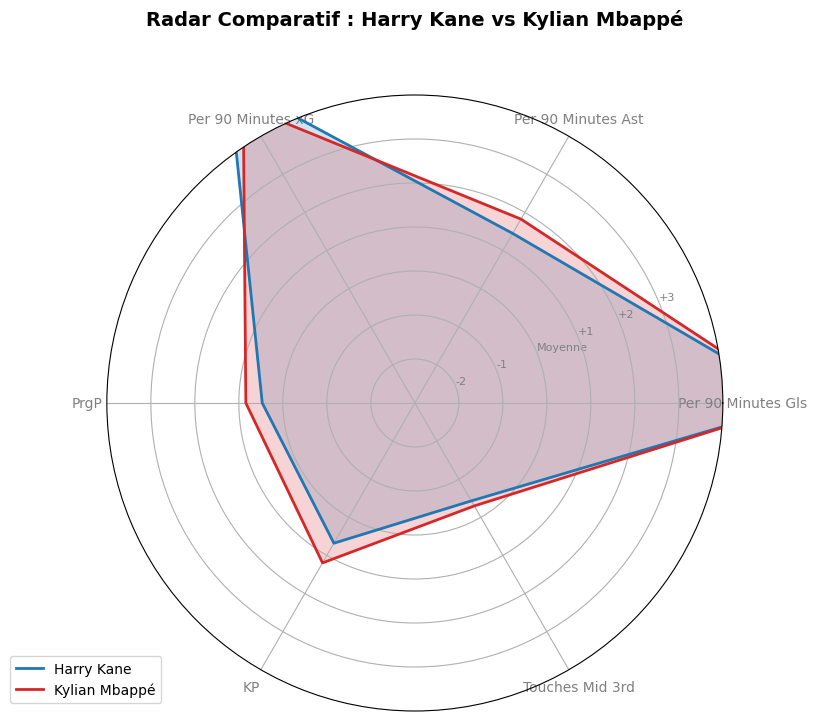

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi

# ==========================================
# ÉTAPE 1 : CHARGEMENT ET FILTRAGE CONTEXTUEL
# ==========================================
# 1. On charge le dataset final
df_final = pd.read_csv('/home/onyxia/Stat_app/data/clean/all_leagues_merged_final_df.csv')
df_final.columns = df_final.columns.str.strip()

# --- NOUVEAU : LE FILTRE DE LA SAISON ---
# Remplace 'season' par le vrai nom de ta colonne si besoin, 
# et '2023-2024' par le format exact de l'année dans ta base.
df_final = df_final[df_final['season'] == 2023].copy()
# ----------------------------------------

# 2. Filtrage : On garde les joueurs pertinents (> 900 min)
df_season = df_final[df_final['Playing Time Min'] >= 900].copy()

# 3. Anti-Doublons (au cas où un joueur a changé de club en plein milieu de la saison 2023)
df_season = df_season.sort_values(by=['player', 'Playing Time Min'], ascending=[True, False])
df_season = df_season.drop_duplicates(subset=['player'], keep='first')
# ==========================================
# ÉTAPE 2 : CALCUL DES Z-SCORES
# ==========================================
# Définition de tes métriques clés (Profil Kane)
stats_to_plot = [
    'Per 90 Minutes Gls', 
    'Per 90 Minutes Ast', 
    'Per 90 Minutes xG', 
    'PrgP', 
    'KP', 
    'Touches Mid 3rd'
]

# Sécurité : on ne garde que les colonnes qui existent vraiment
stats_to_plot = [col for col in stats_to_plot if col in df_season.columns]

# Calcul des Z-scores
cols_zscore = []
for col in stats_to_plot:
    nom_colonne_z = f"{col}_zscore"
    # Calcul du (Valeur - Moyenne) / Ecart-type
    df_season[nom_colonne_z] = (df_season[col] - df_season[col].mean()) / df_season[col].std()
    df_season[nom_colonne_z] = df_season[nom_colonne_z].fillna(0)
    cols_zscore.append(nom_colonne_z)

# ==========================================
# ÉTAPE 3 : FONCTIONS DE SCOUTING & RADAR
# ==========================================
from sklearn.metrics.pairwise import cosine_similarity

# ==========================================
# ÉTAPE 3 : FONCTIONS DE SCOUTING & RADAR (CORRIGÉE)
# ==========================================
def trouver_clones(joueur_cible, df, colonnes_z, top=5):
    """Trouve les profils les plus proches en utilisant la Similarité Cosinus."""
    if joueur_cible not in df['player'].values:
        return f"⚠️ {joueur_cible} introuvable."
    
    # Isoler le profil du joueur cible (format matrice pour scikit-learn)
    cible_stats = df[df['player'] == joueur_cible][colonnes_z].values.reshape(1, -1)
    
    # Toutes les stats de tous les joueurs
    toutes_stats = df[colonnes_z].values
    
    # Calcul de la similarité cosinus (Angle entre les profils)
    similarities = cosine_similarity(cible_stats, toutes_stats)[0]
    
    # Création du DataFrame de résultats
    df_resultats = df[['player']].copy()
    df_resultats['Similarité (%)'] = np.round(similarities * 100, 2)
    
    # Exclure le joueur lui-même et trier
    df_resultats = df_resultats[df_resultats['player'] != joueur_cible]
    df_resultats = df_resultats.sort_values(by='Similarité (%)', ascending=False)
    
    return df_resultats.head(top)

def tracer_radar(joueur1, joueur2, df, colonnes_brutes):
    """Trace le radar chart superposant le joueur cible et son meilleur clone."""
    colonnes_z = [f"{c}_zscore" for c in colonnes_brutes]
    
    val1 = df[df['player'] == joueur1][colonnes_z].values[0].tolist()
    val2 = df[df['player'] == joueur2][colonnes_z].values[0].tolist()
    
    # Fermer le polygone
    val1 += val1[:1]
    val2 += val2[:1]
    
    angles = [n / float(len(colonnes_brutes)) * 2 * pi for n in range(len(colonnes_brutes))]
    angles += angles[:1]
    
    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)
    
    # Tracé Joueur 1 (Bleu)
    ax.plot(angles, val1, linewidth=2, linestyle='solid', label=joueur1, color='#1f77b4')
    ax.fill(angles, val1, '#1f77b4', alpha=0.2)
    
    # Tracé Joueur 2 (Rouge)
    ax.plot(angles, val2, linewidth=2, linestyle='solid', label=joueur2, color='#d62728')
    ax.fill(angles, val2, '#d62728', alpha=0.2)
    
    plt.xticks(angles[:-1], colonnes_brutes, color='grey', size=10)
    plt.yticks([-2, -1, 0, 1, 2, 3], ["-2", "-1", "Moyenne", "+1", "+2", "+3"], color="grey", size=8)
    plt.ylim(-3, 4)
    
    plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))
    plt.title(f"Radar Comparatif : {joueur1} vs {joueur2}", size=14, y=1.1, fontweight='bold')
    plt.show()

# ==========================================
# ÉTAPE 4 : EXÉCUTION
# ==========================================
joueur_a_scouter = "Harry Kane"
df_top5 = trouver_clones(joueur_a_scouter, df_season, cols_zscore, top=5)

print(f"\n🏆 LES 5 MEILLEURS CLONES DE {joueur_a_scouter.upper()} :")
display(df_top5)

# On trace le radar avec le n°1 du classement
meilleur_clone = df_top5.iloc[0]['player']
tracer_radar(joueur_a_scouter, meilleur_clone, df_season, stats_to_plot)

In [3]:
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

# ==========================================
# L'ENTONNOIR DE SCOUTING (LA MÉTHODE PRO)
# ==========================================

def scouting_entonnoir(joueur_cible, df, colonnes_z, top=5):
    if joueur_cible not in df['player'].values:
        return f"⚠️ {joueur_cible} introuvable."
    
    # 1. Filtre de Performance
    df_cible = df[df['player'] == joueur_cible].copy()
    df_candidats = df[df['Per 90 Minutes Gls'] >= 0.40].copy()
    
    if joueur_cible not in df_candidats['player'].values:
        df_candidats = pd.concat([df_candidats, df_cible])
        
    # 2. Le Filtre Tactique Sévere (Distance Euclidienne)
    cible_stats = df_candidats[df_candidats['player'] == joueur_cible][colonnes_z].values[0]
    
    resultats = []
    for index, row in df_candidats.iterrows():
        joueur_actuel = row['player']
        if joueur_actuel == joueur_cible:
            continue
            
        stats_actuelles = row[colonnes_z].values
        
        # Calcul de l'écart exact (Distance Euclidienne)
        distance = np.linalg.norm(cible_stats - stats_actuelles)
        
        # Formule stricte : plus la distance augmente, plus le % chute drastiquement
        # (Diviser par la distance permet d'avoir des scores qui plafonnent de manière réaliste)
        similarite = max(0, 100 - (distance * 12)) 
        
        resultats.append({
            'Joueur': joueur_actuel,
            'Buts / 90min': row['Per 90 Minutes Gls'],
            'Similarité (%)': round(similarite, 2)
        })
        
    df_res = pd.DataFrame(resultats).sort_values(by='Similarité (%)', ascending=False)
    return df_res.head(top)

# ==========================================
# EXÉCUTION DE L'ALGORITHME FUSIONNÉ
# ==========================================
joueur_a_scouter = "Harry Kane"

# On utilise les Z-Scores calculés précédemment
df_top5_fusion = scouting_entonnoir(joueur_a_scouter, df_season, cols_zscore, top=5)

print(f"\n🏆 TOP 5 CLONES DE {joueur_a_scouter.upper()} (Volume Élite + Style Créateur) :")
display(df_top5_fusion)


🏆 TOP 5 CLONES DE HARRY KANE (Volume Élite + Style Créateur) :


,Joueur,Buts / 90min,Similarité (%)
58,Kylian Mbappé,1.13,88.04
33,Erling Haaland,0.95,75.67
92,Serhou Guirassy,1.14,74.12
10,Artem Dovbyk,0.83,69.87
1,Alexander Isak,0.84,67.98



📊 Génération des graphiques en cours...



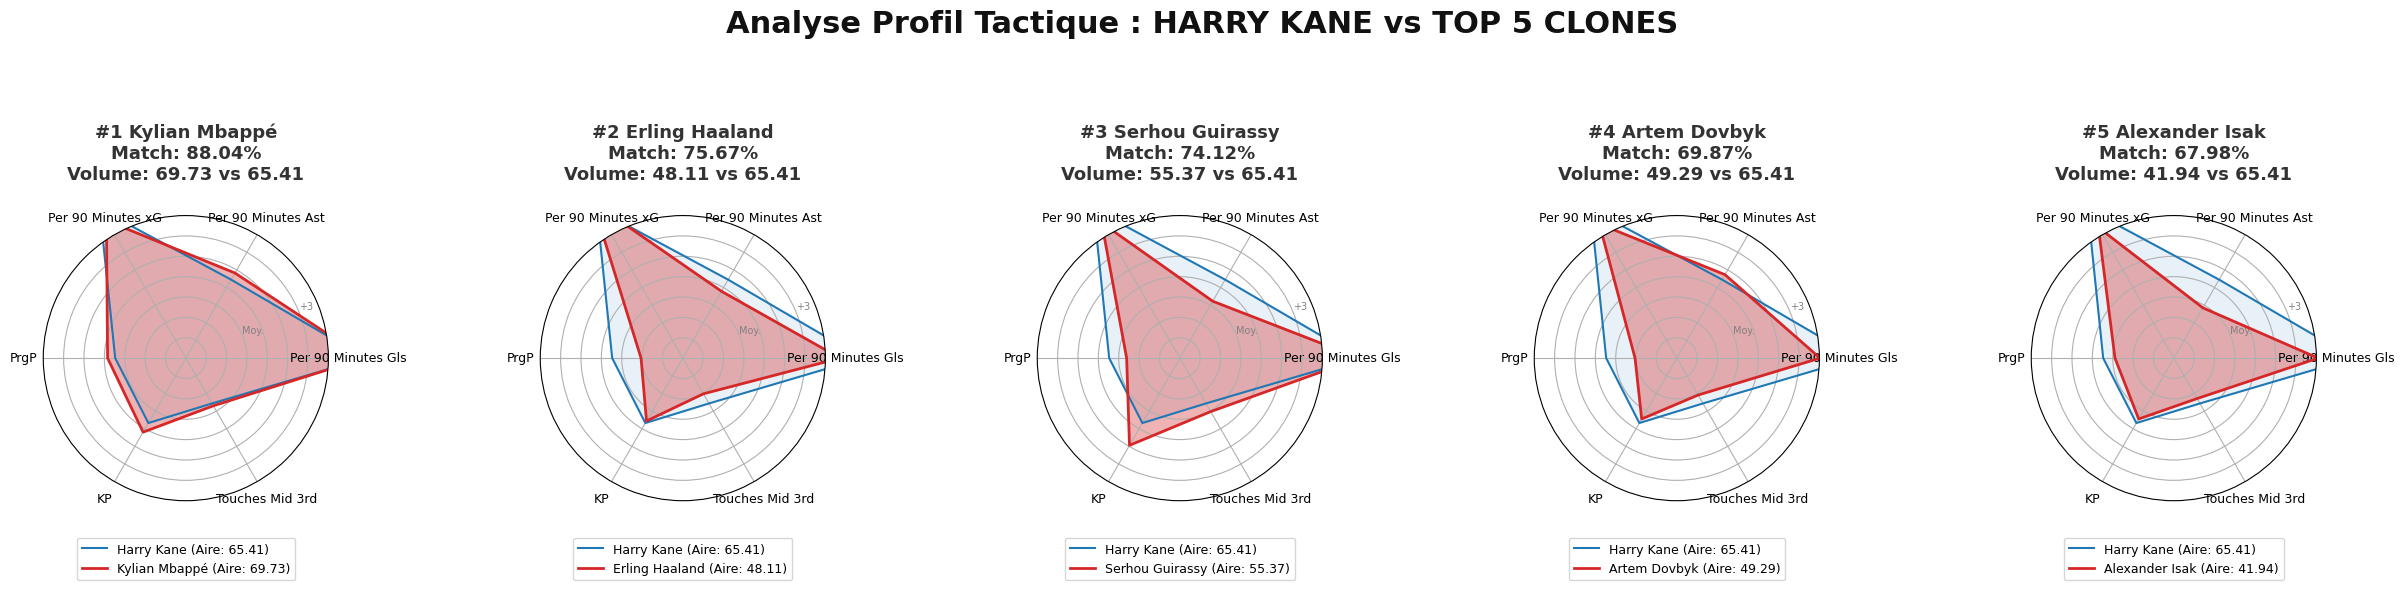

In [4]:
import matplotlib.pyplot as plt
from math import pi
import numpy as np

def calcul_aire_radar(valeurs_zscore):
    """Calcule l'aire du polygone (Volume de jeu) à partir des Z-scores."""
    n = len(valeurs_zscore) - 1 # -1 car la liste est bouclée pour le graphique
    aire_totale = 0
    angle = 2 * pi / n
    for i in range(n):
        # On ajoute +3 pour que le centre du radar (qui est à -3) soit le 0 mathématique de l'aire
        r1 = max(valeurs_zscore[i] + 3, 0) 
        r2 = max(valeurs_zscore[i+1] + 3, 0)
        aire_totale += 0.5 * r1 * r2 * np.sin(angle)
    return round(aire_totale, 2)

def visualiser_top5_radars(joueur_cible, df_top5, df, colonnes_brutes):
    """Affiche une grille de 5 radars comparatifs avec calcul des aires."""
    colonnes_z = [f"{c}_zscore" for c in colonnes_brutes]
    
    # Récupérer et préparer les stats de Kane
    valeurs_cible = df[df['player'] == joueur_cible][colonnes_z].values[0].tolist()
    valeurs_cible += valeurs_cible[:1] # Fermer le polygone
    aire_cible = calcul_aire_radar(valeurs_cible)
    
    # Préparer les angles du radar
    angles = [n / float(len(colonnes_brutes)) * 2 * pi for n in range(len(colonnes_brutes))]
    angles += angles[:1]
    
    # Créer la figure (1 ligne, 5 colonnes)
    fig, axs = plt.subplots(1, 5, figsize=(25, 5), subplot_kw=dict(polar=True))
    fig.suptitle(f"Analyse Profil Tactique : {joueur_cible.upper()} vs TOP 5 CLONES", 
                 size=22, y=1.15, fontweight='bold', color='#111111')
    
    for i, (index, row) in enumerate(df_top5.iterrows()):
        joueur_compare = row['Joueur']
        
        # --- LA CORRECTION EST ICI ---
        # On utilise le bon nom de colonne généré par ton algorithme Euclidien
        similarite = row['Similarité (%)']
        # -----------------------------
        
        # Récupérer les stats du clone
        valeurs_compare = df[df['player'] == joueur_compare][colonnes_z].values[0].tolist()
        valeurs_compare += valeurs_compare[:1]
        aire_compare = calcul_aire_radar(valeurs_compare)
        
        ax = axs[i]
        
        # Tracer Kane (Ligne Bleue)
        ax.plot(angles, valeurs_cible, linewidth=1.5, linestyle='solid', label=f"{joueur_cible} (Aire: {aire_cible})", color='#1f77b4')
        ax.fill(angles, valeurs_cible, '#1f77b4', alpha=0.1)
        
        # Tracer le Clone (Ligne Rouge)
        ax.plot(angles, valeurs_compare, linewidth=2, linestyle='solid', label=f"{joueur_compare} (Aire: {aire_compare})", color='#d62728')
        ax.fill(angles, valeurs_compare, '#d62728', alpha=0.35) 
        
        # Design du radar
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(colonnes_brutes, color='black', size=9) 
        ax.set_yticks([-2, -1, 0, 1, 2, 3])
        ax.set_yticklabels(["", "", "Moy.", "", "", "+3"], color="grey", size=7)
        ax.set_ylim(-3, 4)
        
        # Titre de chaque sous-graphique
        titre = f"#{i+1} {joueur_compare}\nMatch: {similarite}%\nVolume: {aire_compare} vs {aire_cible}"
        ax.set_title(titre, size=13, fontweight='bold', color='#333333', y=1.1)
        
        # Ajouter la légende au centre de chaque radar
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.3), fontsize=9)
            
    plt.tight_layout()
    plt.show()

# ==========================================
# EXÉCUTION DE L'AFFICHAGE MULTIPLE
# ==========================================
print("\n📊 Génération des graphiques en cours...\n")
visualiser_top5_radars("Harry Kane", df_top5_fusion, df_season, stats_to_plot)

In [5]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

def scouting_hybride(joueur_cible, df, colonnes_z, top=5):
    """L'algorithme Ultime : Combine le Style Tactique (Cosinus) et le Volume (Euclidienne)."""
    if joueur_cible not in df['player'].values:
        return f"⚠️ {joueur_cible} introuvable."
    
    # 1. Le Filtre de Buteurs (On garde les bons finisseurs > 0.40 buts/90)
    df_cible = df[df['player'] == joueur_cible].copy()
    df_candidats = df[df['Per 90 Minutes Gls'] >= 0.40].copy()
    if joueur_cible not in df_candidats['player'].values:
        df_candidats = pd.concat([df_candidats, df_cible])
        
    cible_stats = df_candidats[df_candidats['player'] == joueur_cible][colonnes_z].values[0]
    cible_stats_matrice = cible_stats.reshape(1, -1)
    
    resultats = []
    
    for index, row in df_candidats.iterrows():
        joueur_actuel = row['player']
        if joueur_actuel == joueur_cible:
            continue
            
        stats_actuelles = row[colonnes_z].values
        stats_matrice = stats_actuelles.reshape(1, -1)
        
        # --- A. LE SCORE TACTIQUE (Cosinus) ---
        # Note l'angle du radar (Est-ce qu'il décroche et fait des passes comme Kane ?)
        score_tactique = cosine_similarity(cible_stats_matrice, stats_matrice)[0][0]
        # On le remet sur 100
        note_tactique = max(0, score_tactique * 100)
        
        # --- B. LE SCORE DE VOLUME (Euclidienne) ---
        # Note la distance (Est-ce qu'il marque autant et produit autant de jeu ?)
        distance = np.linalg.norm(cible_stats - stats_actuelles)
        note_volume = max(0, 100 - (distance * 12)) 
        
        # --- C. LE SCORE HYBRIDE FINAL ---
        # On donne 60% d'importance au Style Tactique, et 40% au Volume
        score_final = (note_tactique * 0.60) + (note_volume * 0.40)
        
        resultats.append({
            'Joueur': joueur_actuel,
            'Buts / 90min': row['Per 90 Minutes Gls'],
            'Score Tactique': round(note_tactique, 1),
            'Score Volume': round(note_volume, 1),
            'Similarité Globale (%)': round(score_final, 2)
        })
        
    df_res = pd.DataFrame(resultats).sort_values(by='Similarité Globale (%)', ascending=False)
    return df_res.head(top)

# Exécution du modèle Hybride
df_top5_ultime = scouting_hybride("Harry Kane", df_season, cols_zscore, top=5)
display(df_top5_ultime)

,Joueur,Buts / 90min,Score Tactique,Score Volume,Similarité Globale (%)
58,Kylian Mbappé,1.13,99.3,88.0,94.79
33,Erling Haaland,0.95,96.9,75.7,88.40
92,Serhou Guirassy,1.14,96.5,74.1,87.52
10,Artem Dovbyk,0.83,96.6,69.9,85.93
61,Loïs Openda,0.80,98.0,67.3,85.69


🔎 Lancement de l'algorithme pour : Harry Kane...

🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :


,player,team,league,age,Similarite_Score
0,Erling Haaland,Manchester City,ENG-Premier League,23.000000,64.0%
1,Kylian Mbappé,Paris S-G,FRA-Ligue 1,24.000000,61.9%
2,Loïs Openda,RB Leipzig,GER-Bundesliga,23.000000,47.7%
3,Serhou Guirassy,Stuttgart,GER-Bundesliga,27.000000,47.1%
4,Artem Dovbyk,Girona,ESP-La Liga,26.000000,33.3%



📊 Génération des radars en cours...


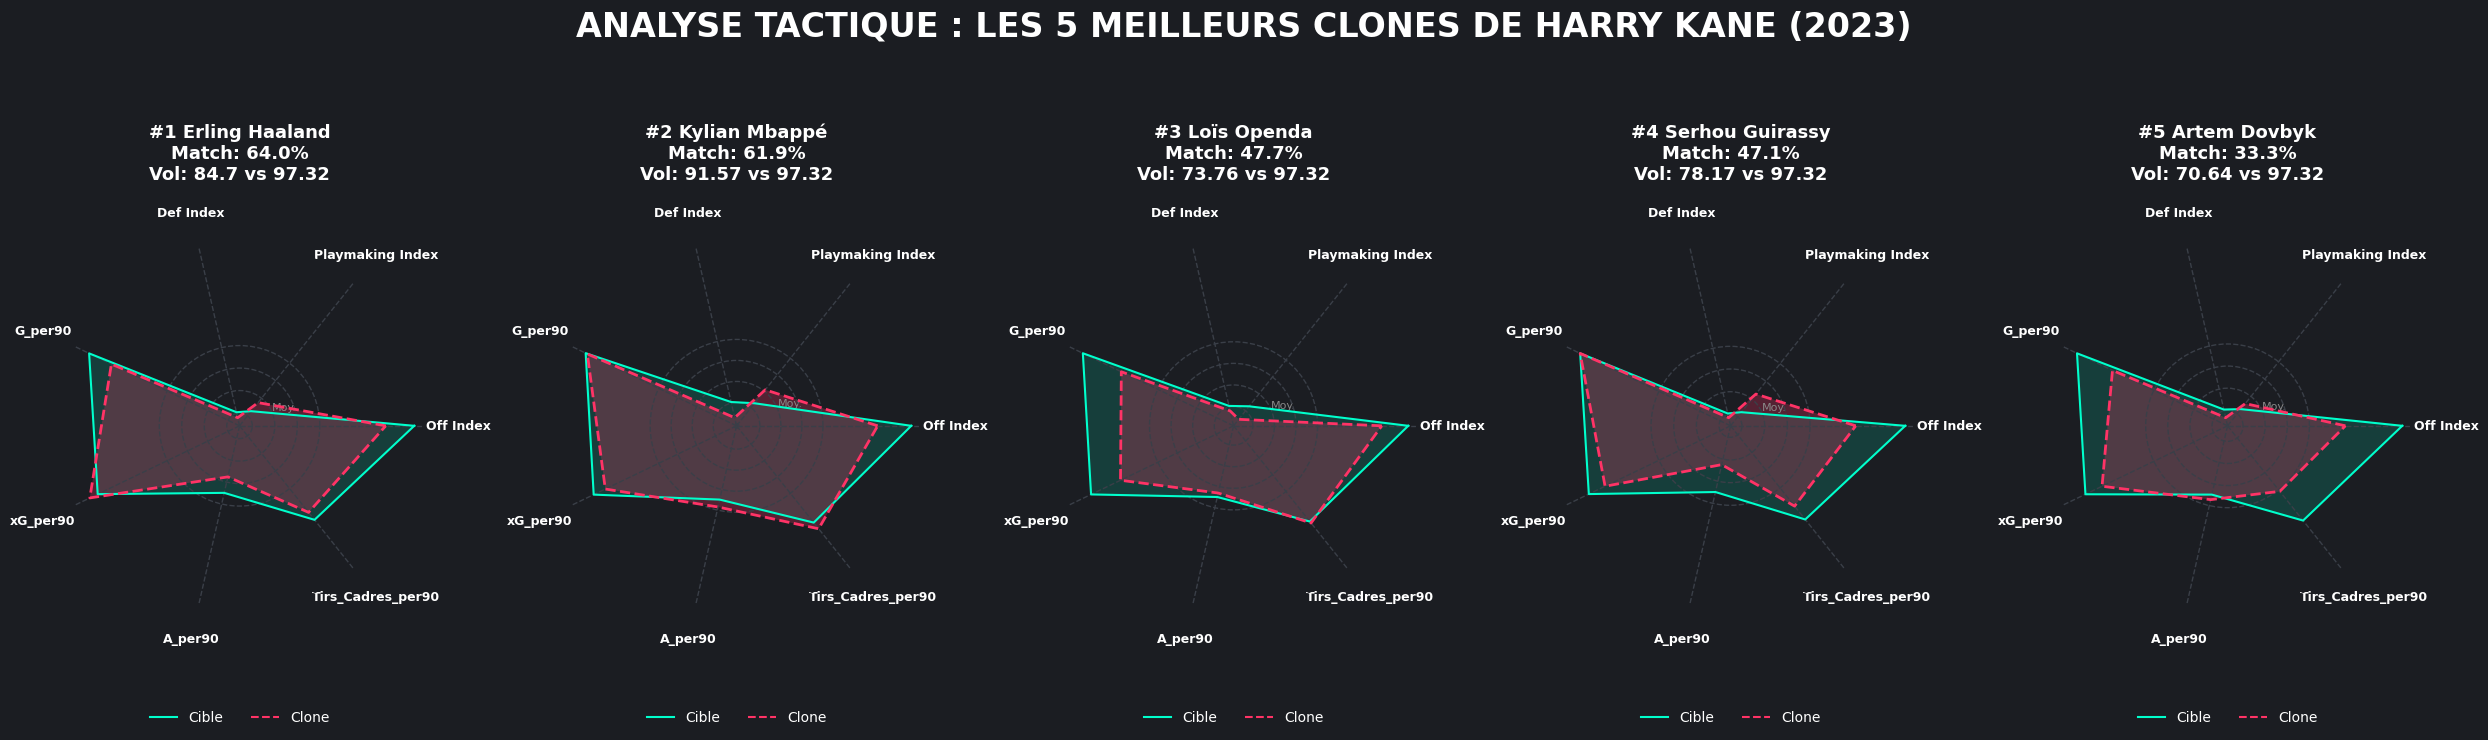

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⚙️ 1. PARAMÈTRES DE RECHERCHE
# ==========================================
SAISON_ANALYSE = 2023         # Change l'année ici (2020, 2021, 2022, 2023)
JOUEUR_CIBLE = "Harry Kane"   # Change le joueur ici

# ==========================================
# 2. CHARGEMENT ET PRÉPARATION
# ==========================================
df_master = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v3_master_ml.csv")
df_saison = df_master[(df_master['season'] == SAISON_ANALYSE) & (df_master['Minutes de jeu'] >= 900)].copy()

kpi_scouting = [
    "Off Index", "Playmaking Index", "Def Index", 
    "G_per90", "xG_per90", "A_per90", "Tirs_Cadres_per90"
]

# Standardisation (Z-Score)
scaler = StandardScaler()
z_cols = [f"{c}_z" for c in kpi_scouting]
df_saison[z_cols] = scaler.fit_transform(df_saison[kpi_scouting].fillna(0))
df_saison = df_saison.reset_index(drop=True)

# ==========================================
# 3. LE MOTEUR DE RECHERCHE (KNN)
# ==========================================
def scouting_entonnoir(joueur_cible, df, colonnes_z, top_n=5):
    joueur_cible = joueur_cible.strip()
    if not df['player'].str.contains(joueur_cible, case=False, na=False).any():
        return None, f"⚠️ Joueur '{joueur_cible}' introuvable en {SAISON_ANALYSE} (>900 min)."
    
    cible_idx = df[df['player'].str.contains(joueur_cible, case=False, na=False)].index[0]
    nom_exact = df.loc[cible_idx, 'player']
    poste_cible = df.loc[cible_idx, 'pos']
    cible_stats = df.loc[cible_idx, colonnes_z].values.reshape(1, -1)
    
    poste_principal = poste_cible.split(',')[0]
    df_candidats = df[df['pos'].str.contains(poste_principal, na=False)].copy()
    
    if cible_idx not in df_candidats.index:
        df_candidats = pd.concat([df_candidats, df.loc[[cible_idx]]])
    df_candidats = df_candidats.reset_index(drop=True)
    
    knn = NearestNeighbors(n_neighbors=top_n + 1, metric='euclidean')
    knn.fit(df_candidats[colonnes_z].values)
    distances, indices = knn.kneighbors(cible_stats)
    
    df_resultats = df_candidats.iloc[indices[0]].copy()
    df_resultats['Distance'] = distances[0]
    
    max_dist = df_resultats['Distance'].max()
    if max_dist > 0:
        df_resultats['Similarite_Score'] = 100 * (1 - (df_resultats['Distance'] / (max_dist * 1.5)))
    else:
        df_resultats['Similarite_Score'] = 100.0
        
    return df_resultats.iloc[1:].reset_index(drop=True), nom_exact

# ==========================================
# 4. LA VISUALISATION DES 5 RADARS (PRO DARK MODE)
# ==========================================
def calcul_aire_radar(valeurs_zscore):
    n = len(valeurs_zscore) - 1
    aire_totale = 0
    angle = 2 * pi / n
    for i in range(n):
        r1 = max(valeurs_zscore[i] + 3, 0) 
        r2 = max(valeurs_zscore[i+1] + 3, 0)
        aire_totale += 0.5 * r1 * r2 * np.sin(angle)
    return round(aire_totale, 2)

def visualiser_top5_radars_pro(joueur_cible, df_top5, df, colonnes_z, kpi_names):
    valeurs_cible = df[df['player'] == joueur_cible][colonnes_z].values[0].tolist()
    valeurs_cible += valeurs_cible[:1] 
    aire_cible = calcul_aire_radar(valeurs_cible)
    
    angles = [n / float(len(kpi_names)) * 2 * pi for n in range(len(kpi_names))]
    angles += angles[:1]
    
    couleur_fond = '#1b1d22'
    couleur_cible = '#00ffcc'     # Cyan
    couleur_candidat = '#ff3366'  # Rose
    
    fig, axs = plt.subplots(1, 5, figsize=(25, 6), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(couleur_fond)
    fig.suptitle(f"ANALYSE TACTIQUE : LES 5 MEILLEURS CLONES DE {joueur_cible.upper()} ({SAISON_ANALYSE})", 
                 size=24, y=1.15, fontweight='bold', color='white')
    
    for i, (index, row) in enumerate(df_top5.head(5).iterrows()):
        joueur_compare = row['player']
        similarite = row['Similarite_Score']
        
        valeurs_compare = df[df['player'] == joueur_compare][colonnes_z].values[0].tolist()
        valeurs_compare += valeurs_compare[:1]
        aire_compare = calcul_aire_radar(valeurs_compare)
        
        ax = axs[i]
        ax.set_facecolor(couleur_fond)
        ax.set_rmin(-3)
        ax.set_rmax(3)
        ax.grid(color='#3a3f48', linestyle='--', linewidth=1)
        ax.spines['polar'].set_color(couleur_fond)
        
        ax.plot(angles, valeurs_cible, linewidth=1.5, linestyle='solid', color=couleur_cible)
        ax.fill(angles, valeurs_cible, couleur_cible, alpha=0.15)
        
        ax.plot(angles, valeurs_compare, linewidth=2, linestyle='dashed', color=couleur_candidat)
        ax.fill(angles, valeurs_compare, couleur_candidat, alpha=0.25) 
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(kpi_names, color='white', size=9, fontweight='bold')
        ax.tick_params(axis='x', pad=15)
        
        ax.set_yticks([-2, -1, 0, 1, 2])
        ax.set_yticklabels(["", "", "Moy.", "", ""], color="#888888", size=8)
        
        titre = f"#{i+1} {joueur_compare}\nMatch: {similarite:.1f}%\nVol: {aire_compare} vs {aire_cible}"
        ax.set_title(titre, size=13, fontweight='bold', color='white', y=1.15)
        
        # Ajout d'une petite légende personnalisée pour chaque radar
        ax.plot([], [], color=couleur_cible, label="Cible")
        ax.plot([], [], color=couleur_candidat, linestyle='dashed', label="Clone")
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), fontsize=10, 
                  facecolor=couleur_fond, edgecolor=couleur_fond, labelcolor='white', ncol=2)
            
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXÉCUTION DU SCRIPT
# ==========================================
print(f"🔎 Lancement de l'algorithme pour : {JOUEUR_CIBLE}...")
df_top_clones, vrai_nom = scouting_entonnoir(JOUEUR_CIBLE, df_saison, z_cols, top_n=5)

if df_top_clones is not None:
    print(f"\n🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :")
    colonnes_affichage = ['player', 'team', 'league', 'age', 'Similarite_Score']
    display(df_top_clones[colonnes_affichage].style.format({'Similarite_Score': "{:.1f}%"}))
    
    print("\n📊 Génération des radars en cours...")
    visualiser_top5_radars_pro(vrai_nom, df_top_clones, df_saison, z_cols, kpi_scouting)
else:
    print(vrai_nom)

🔎 Lancement de l'algorithme Hybride pour : Harry Kane...

🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :


,player,team,league,age,Score_Tactique,Score_Volume,Similarite_Score
101,Erling Haaland,Manchester City,ENG-Premier League,23.000000,98.9,76.1,89.8%
207,Kylian Mbappé,Paris S-G,FRA-Ligue 1,24.000000,98.3,74.7,88.9%
219,Loïs Openda,RB Leipzig,GER-Bundesliga,23.000000,98.3,65.2,85.1%
336,Serhou Guirassy,Stuttgart,GER-Bundesliga,27.000000,97.5,64.9,84.4%
36,Artem Dovbyk,Girona,ESP-La Liga,26.000000,98.0,55.7,81.1%



📊 Génération des radars en cours...


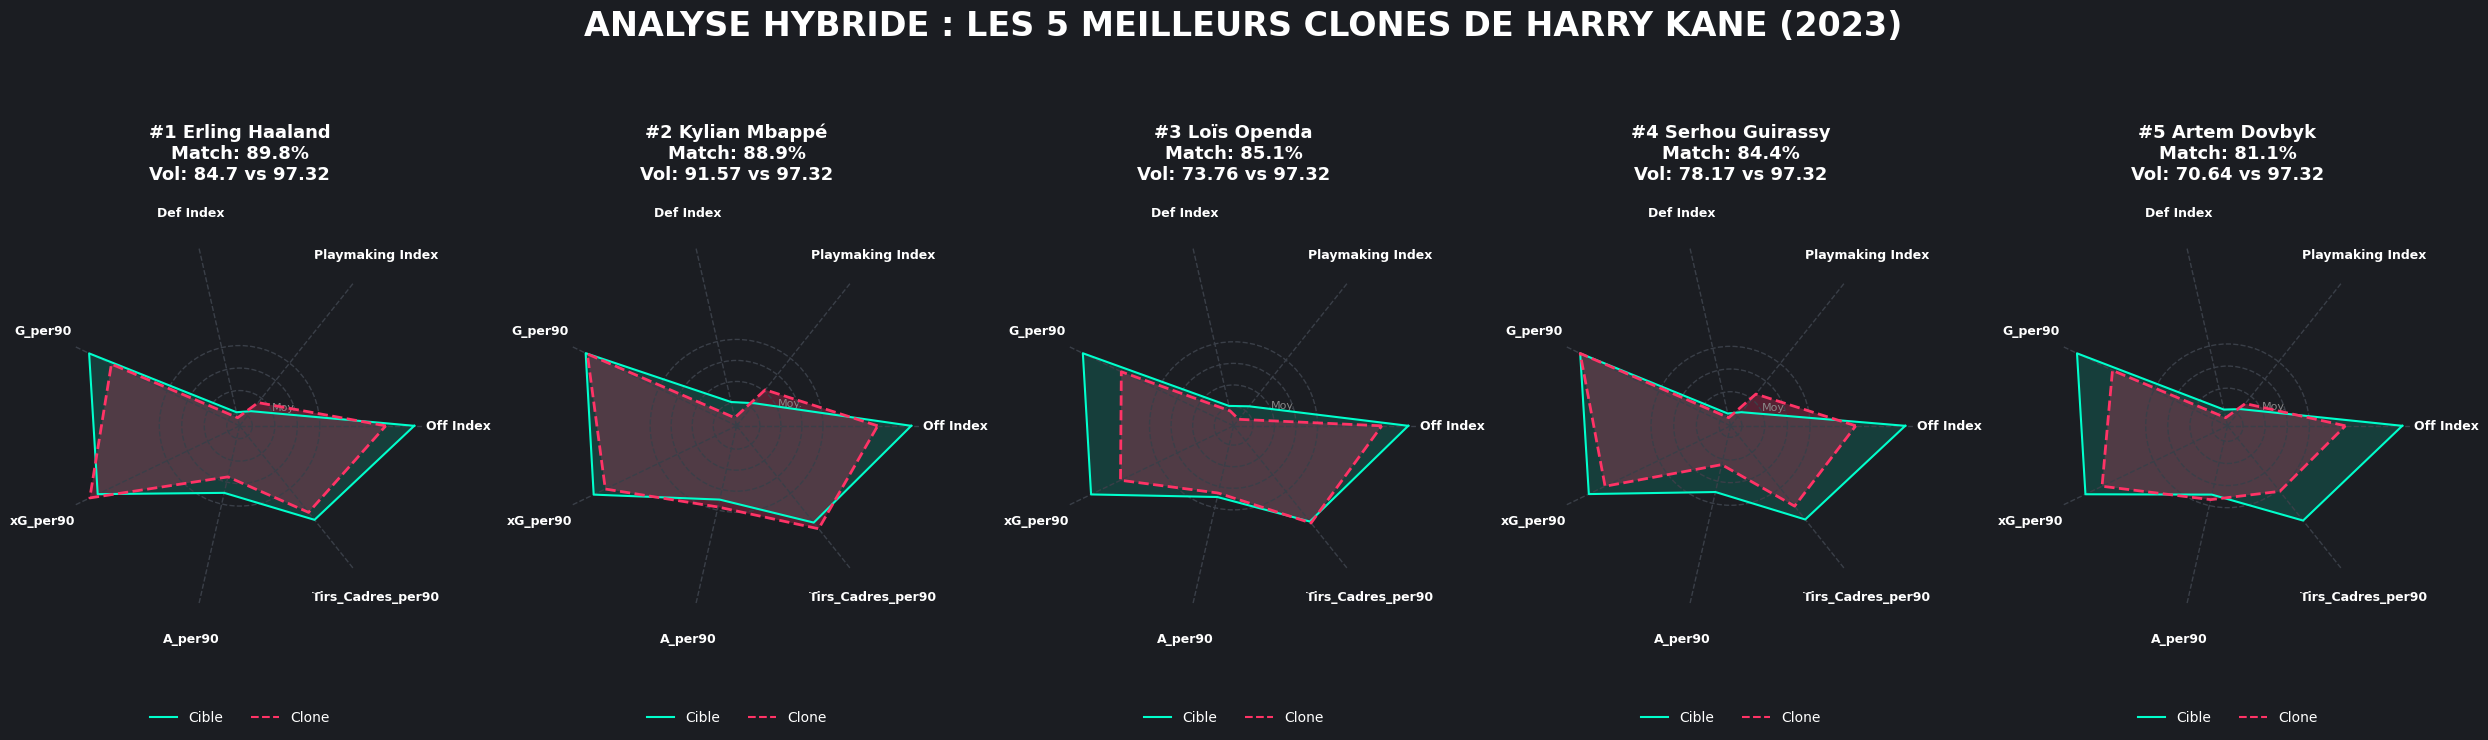

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⚙️ 1. PARAMÈTRES DE RECHERCHE
# ==========================================
SAISON_ANALYSE = 2023 
JOUEUR_CIBLE = "Harry Kane" 

# ==========================================
# 2. CHARGEMENT ET PRÉPARATION
# ==========================================
df_master = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v3_master_ml.csv")
df_saison = df_master[(df_master['season'] == SAISON_ANALYSE) & (df_master['Minutes de jeu'] >= 900)].copy()

kpi_scouting = [
    "Off Index", "Playmaking Index", "Def Index", 
    "G_per90", "xG_per90", "A_per90", "Tirs_Cadres_per90"
]

scaler = StandardScaler()
z_cols = [f"{c}_z" for c in kpi_scouting]
df_saison[z_cols] = scaler.fit_transform(df_saison[kpi_scouting].fillna(0))
df_saison = df_saison.reset_index(drop=True)

# ==========================================
# 3. LE MOTEUR DE RECHERCHE (L'HYBRIDE DE TON AMI)
# ==========================================
def scouting_entonnoir_hybride(joueur_cible, df, colonnes_z, top_n=5):
    joueur_cible = joueur_cible.strip()
    if not df['player'].str.contains(joueur_cible, case=False, na=False).any():
        return None, f"⚠️ Joueur '{joueur_cible}' introuvable en {SAISON_ANALYSE}."
    
    cible_idx = df[df['player'].str.contains(joueur_cible, case=False, na=False)].index[0]
    nom_exact = df.loc[cible_idx, 'player']
    poste_cible = df.loc[cible_idx, 'pos']
    
    cible_stats = df.loc[cible_idx, colonnes_z].values
    cible_stats_matrice = cible_stats.reshape(1, -1)
    
    # Filtre sur le poste (pour éviter de comparer Bellingham à un Défenseur Central)
    poste_principal = poste_cible.split(',')[0]
    df_candidats = df[df['pos'].str.contains(poste_principal, na=False)].copy()
    
    resultats = []
    
    for index, row in df_candidats.iterrows():
        joueur_actuel = row['player']
        if joueur_actuel == nom_exact:
            continue
            
        stats_actuelles = row[colonnes_z].values
        stats_matrice = stats_actuelles.reshape(1, -1)
        
        # --- A. SCORE TACTIQUE (Cosinus = Forme du jeu) ---
        score_tactique = cosine_similarity(cible_stats_matrice, stats_matrice)[0][0]
        note_tactique = max(0, score_tactique * 100)
        
        # --- B. SCORE VOLUME (Euclidienne = Quantité de jeu) ---
        distance = np.linalg.norm(cible_stats - stats_actuelles)
        note_volume = max(0, 100 - (distance * 12)) 
        
        # --- C. HYBRIDE (60% Forme / 40% Volume) ---
        score_final = (note_tactique * 0.60) + (note_volume * 0.40)
        
        resultats.append({
            'player': joueur_actuel,
            'team': row['team'],
            'league': row['league'],
            'age': row['age'],
            'Score_Tactique': note_tactique,
            'Score_Volume': note_volume,
            'Similarite_Score': score_final
        })
        
    df_res = pd.DataFrame(resultats).sort_values(by='Similarite_Score', ascending=False)
    return df_res.head(top_n), nom_exact

# ==========================================
# 4. LA VISUALISATION (PRO DARK MODE)
# ==========================================
def calcul_aire_radar(valeurs_zscore):
    n = len(valeurs_zscore) - 1
    aire_totale = 0
    angle = 2 * pi / n
    for i in range(n):
        r1 = max(valeurs_zscore[i] + 3, 0) 
        r2 = max(valeurs_zscore[i+1] + 3, 0)
        aire_totale += 0.5 * r1 * r2 * np.sin(angle)
    return round(aire_totale, 2)

def visualiser_top5_radars_pro(joueur_cible, df_top5, df, colonnes_z, kpi_names):
    valeurs_cible = df[df['player'] == joueur_cible][colonnes_z].values[0].tolist()
    valeurs_cible += valeurs_cible[:1] 
    aire_cible = calcul_aire_radar(valeurs_cible)
    
    angles = [n / float(len(kpi_names)) * 2 * pi for n in range(len(kpi_names))]
    angles += angles[:1]
    
    couleur_fond = '#1b1d22'
    couleur_cible = '#00ffcc'     # Cyan
    couleur_candidat = '#ff3366'  # Rose
    
    fig, axs = plt.subplots(1, 5, figsize=(25, 6), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(couleur_fond)
    fig.suptitle(f"ANALYSE HYBRIDE : LES 5 MEILLEURS CLONES DE {joueur_cible.upper()} ({SAISON_ANALYSE})", 
                 size=24, y=1.15, fontweight='bold', color='white')
    
    for i, (index, row) in enumerate(df_top5.head(5).iterrows()):
        joueur_compare = row['player']
        similarite = row['Similarite_Score']
        
        valeurs_compare = df[df['player'] == joueur_compare][colonnes_z].values[0].tolist()
        valeurs_compare += valeurs_compare[:1]
        aire_compare = calcul_aire_radar(valeurs_compare)
        
        ax = axs[i]
        ax.set_facecolor(couleur_fond)
        ax.set_rmin(-3)
        ax.set_rmax(3)
        ax.grid(color='#3a3f48', linestyle='--', linewidth=1)
        ax.spines['polar'].set_color(couleur_fond)
        
        ax.plot(angles, valeurs_cible, linewidth=1.5, linestyle='solid', color=couleur_cible)
        ax.fill(angles, valeurs_cible, couleur_cible, alpha=0.15)
        
        ax.plot(angles, valeurs_compare, linewidth=2, linestyle='dashed', color=couleur_candidat)
        ax.fill(angles, valeurs_compare, couleur_candidat, alpha=0.25) 
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(kpi_names, color='white', size=9, fontweight='bold')
        ax.tick_params(axis='x', pad=15)
        
        ax.set_yticks([-2, -1, 0, 1, 2])
        ax.set_yticklabels(["", "", "Moy.", "", ""], color="#888888", size=8)
        
        titre = f"#{i+1} {joueur_compare}\nMatch: {similarite:.1f}%\nVol: {aire_compare} vs {aire_cible}"
        ax.set_title(titre, size=13, fontweight='bold', color='white', y=1.15)
        
        ax.plot([], [], color=couleur_cible, label="Cible")
        ax.plot([], [], color=couleur_candidat, linestyle='dashed', label="Clone")
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), fontsize=10, 
                  facecolor=couleur_fond, edgecolor=couleur_fond, labelcolor='white', ncol=2)
            
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXÉCUTION DU SCRIPT
# ==========================================
print(f"🔎 Lancement de l'algorithme Hybride pour : {JOUEUR_CIBLE}...")
df_top_clones, vrai_nom = scouting_entonnoir_hybride(JOUEUR_CIBLE, df_saison, z_cols, top_n=5)

if df_top_clones is not None:
    print(f"\n🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :")
    colonnes_affichage = ['player', 'team', 'league', 'age', 'Score_Tactique', 'Score_Volume', 'Similarite_Score']
    display(df_top_clones[colonnes_affichage].style.format({
        'Score_Tactique': "{:.1f}", 
        'Score_Volume': "{:.1f}", 
        'Similarite_Score': "{:.1f}%"
    }))
    
    print("\n📊 Génération des radars en cours...")
    visualiser_top5_radars_pro(vrai_nom, df_top_clones, df_saison, z_cols, kpi_scouting)
else:
    print(vrai_nom)

🔎 Lancement de l'algorithme Hybride pour : Lionel Messi...

🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :


,player,team,league,age,Score_Tactique,Score_Volume,Similarite_Score
245,Karim Benzema,Real Madrid,ESP-La Liga,32.000000,98.4,54.0,98.4%
369,Patrick Bamford,Leeds United,ENG-Premier League,26.000000,98.2,36.0,98.2%
50,Arnaud Kalimuendo,Paris S-G,FRA-Ligue 1,18.000000,97.9,22.6,97.9%
332,Mohamed Salah,Liverpool,ENG-Premier League,28.000000,97.8,42.3,97.8%
274,Lorenzo Insigne,Napoli,ITA-Serie A,29.000000,97.8,34.7,97.8%



📊 Génération des radars en cours...


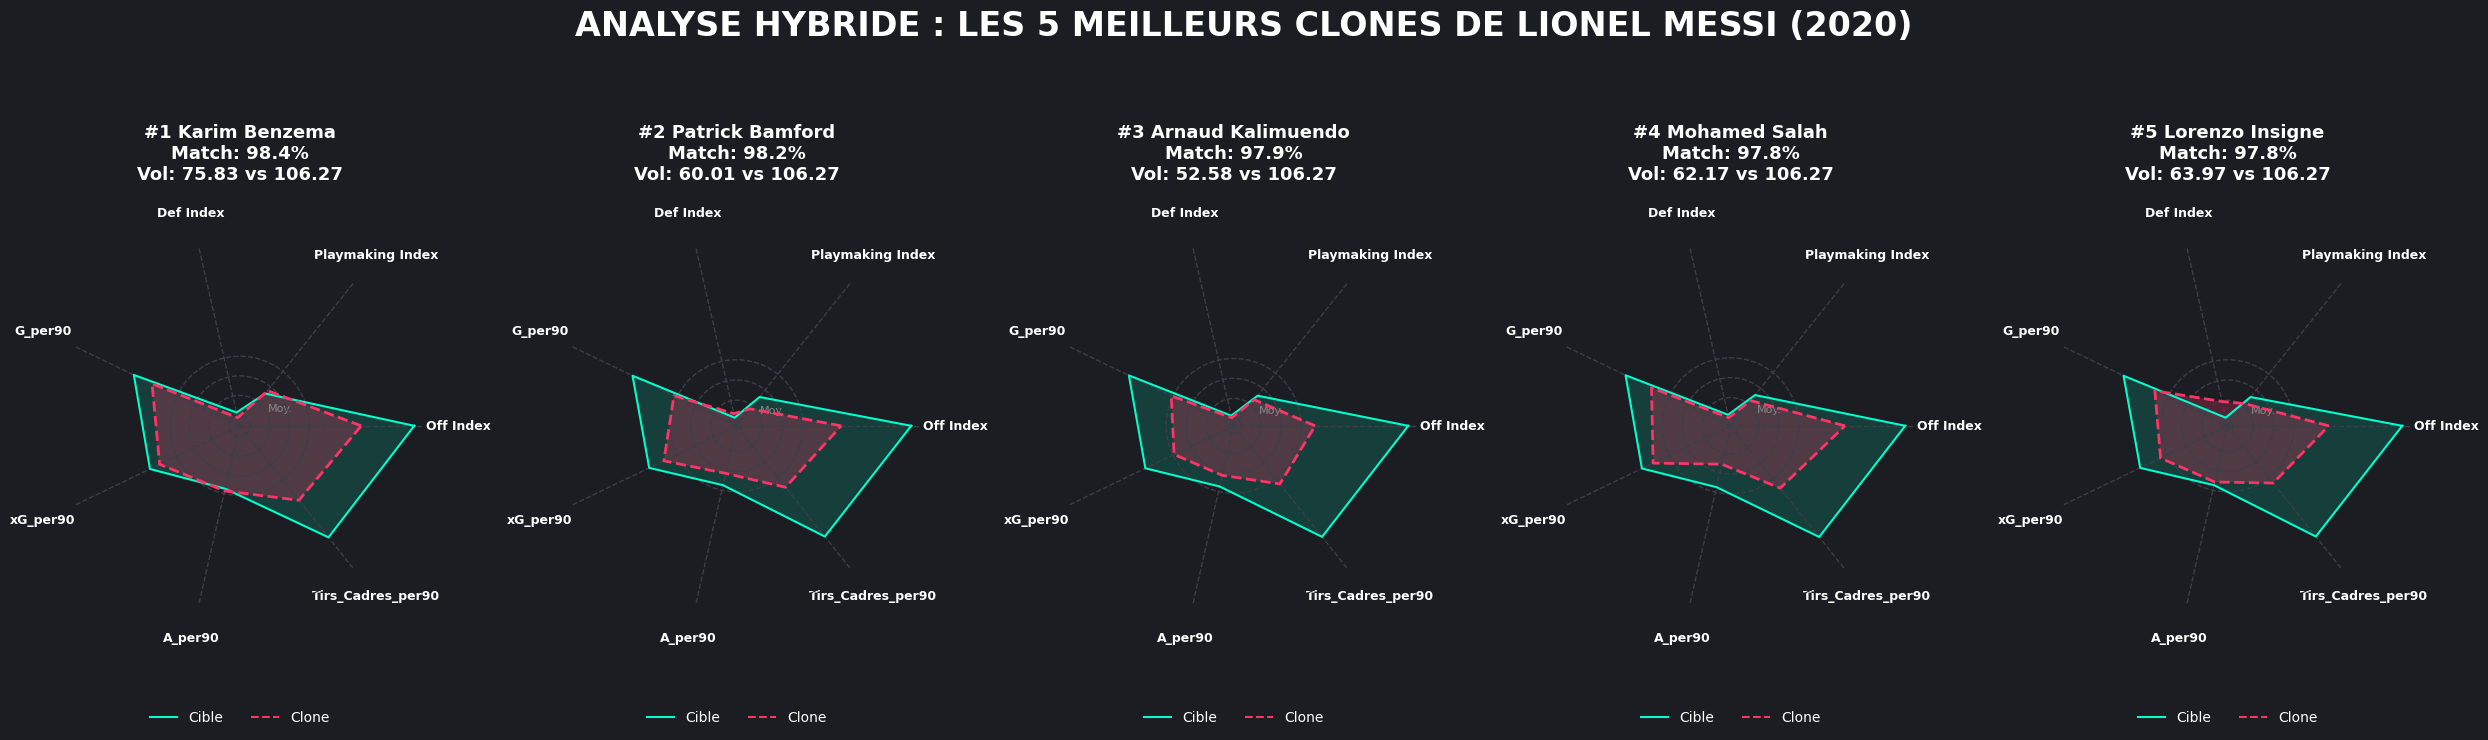

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⚙️ 1. PARAMÈTRES DE RECHERCHE
# ==========================================
SAISON_ANALYSE = 2020
JOUEUR_CIBLE = "Lionel Messi" 

# ==========================================
# 2. CHARGEMENT ET PRÉPARATION
# ==========================================
df_master = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v3_master_ml.csv")
df_saison = df_master[(df_master['season'] == SAISON_ANALYSE) & (df_master['Minutes de jeu'] >= 900)].copy()

kpi_scouting = [
    "Off Index", "Playmaking Index", "Def Index", 
    "G_per90", "xG_per90", "A_per90", "Tirs_Cadres_per90"
]

scaler = StandardScaler()
z_cols = [f"{c}_z" for c in kpi_scouting]
df_saison[z_cols] = scaler.fit_transform(df_saison[kpi_scouting].fillna(0))
df_saison = df_saison.reset_index(drop=True)

# ==========================================
# 3. LE MOTEUR DE RECHERCHE (L'HYBRIDE DE TON AMI)
# ==========================================
def scouting_entonnoir_hybride(joueur_cible, df, colonnes_z, top_n=5):
    joueur_cible = joueur_cible.strip()
    if not df['player'].str.contains(joueur_cible, case=False, na=False).any():
        return None, f"⚠️ Joueur '{joueur_cible}' introuvable en {SAISON_ANALYSE}."
    
    cible_idx = df[df['player'].str.contains(joueur_cible, case=False, na=False)].index[0]
    nom_exact = df.loc[cible_idx, 'player']
    poste_cible = df.loc[cible_idx, 'pos']
    
    cible_stats = df.loc[cible_idx, colonnes_z].values
    cible_stats_matrice = cible_stats.reshape(1, -1)
    
    # Filtre sur le poste (pour éviter de comparer Bellingham à un Défenseur Central)
    poste_principal = poste_cible.split(',')[0]
    df_candidats = df[df['pos'].str.contains(poste_principal, na=False)].copy()
    
    resultats = []
    
    for index, row in df_candidats.iterrows():
        joueur_actuel = row['player']
        if joueur_actuel == nom_exact:
            continue
            
        stats_actuelles = row[colonnes_z].values
        stats_matrice = stats_actuelles.reshape(1, -1)
        
        # --- A. SCORE TACTIQUE (Cosinus = Forme du jeu) ---
        score_tactique = cosine_similarity(cible_stats_matrice, stats_matrice)[0][0]
        note_tactique = max(0, score_tactique * 100)
        
        # --- B. SCORE VOLUME (Euclidienne = Quantité de jeu) ---
        distance = np.linalg.norm(cible_stats - stats_actuelles)
        note_volume = max(0, 100 - (distance * 12)) 
        
        # --- C. HYBRIDE (60% Forme / 40% Volume) ---
        score_final = (note_tactique * 1.00) + (note_volume * 0.00)
        
        resultats.append({
            'player': joueur_actuel,
            'team': row['team'],
            'league': row['league'],
            'age': row['age'],
            'Score_Tactique': note_tactique,
            'Score_Volume': note_volume,
            'Similarite_Score': score_final
        })
        
    df_res = pd.DataFrame(resultats).sort_values(by='Similarite_Score', ascending=False)
    return df_res.head(top_n), nom_exact

# ==========================================
# 4. LA VISUALISATION (PRO DARK MODE)
# ==========================================
def calcul_aire_radar(valeurs_zscore):
    n = len(valeurs_zscore) - 1
    aire_totale = 0
    angle = 2 * pi / n
    for i in range(n):
        r1 = max(valeurs_zscore[i] + 3, 0) 
        r2 = max(valeurs_zscore[i+1] + 3, 0)
        aire_totale += 0.5 * r1 * r2 * np.sin(angle)
    return round(aire_totale, 2)

def visualiser_top5_radars_pro(joueur_cible, df_top5, df, colonnes_z, kpi_names):
    valeurs_cible = df[df['player'] == joueur_cible][colonnes_z].values[0].tolist()
    valeurs_cible += valeurs_cible[:1] 
    aire_cible = calcul_aire_radar(valeurs_cible)
    
    angles = [n / float(len(kpi_names)) * 2 * pi for n in range(len(kpi_names))]
    angles += angles[:1]
    
    couleur_fond = '#1b1d22'
    couleur_cible = '#00ffcc'     # Cyan
    couleur_candidat = '#ff3366'  # Rose
    
    fig, axs = plt.subplots(1, 5, figsize=(25, 6), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(couleur_fond)
    fig.suptitle(f"ANALYSE HYBRIDE : LES 5 MEILLEURS CLONES DE {joueur_cible.upper()} ({SAISON_ANALYSE})", 
                 size=24, y=1.15, fontweight='bold', color='white')
    
    for i, (index, row) in enumerate(df_top5.head(5).iterrows()):
        joueur_compare = row['player']
        similarite = row['Similarite_Score']
        
        valeurs_compare = df[df['player'] == joueur_compare][colonnes_z].values[0].tolist()
        valeurs_compare += valeurs_compare[:1]
        aire_compare = calcul_aire_radar(valeurs_compare)
        
        ax = axs[i]
        ax.set_facecolor(couleur_fond)
        ax.set_rmin(-3)
        ax.set_rmax(3)
        ax.grid(color='#3a3f48', linestyle='--', linewidth=1)
        ax.spines['polar'].set_color(couleur_fond)
        
        ax.plot(angles, valeurs_cible, linewidth=1.5, linestyle='solid', color=couleur_cible)
        ax.fill(angles, valeurs_cible, couleur_cible, alpha=0.15)
        
        ax.plot(angles, valeurs_compare, linewidth=2, linestyle='dashed', color=couleur_candidat)
        ax.fill(angles, valeurs_compare, couleur_candidat, alpha=0.25) 
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(kpi_names, color='white', size=9, fontweight='bold')
        ax.tick_params(axis='x', pad=15)
        
        ax.set_yticks([-2, -1, 0, 1, 2])
        ax.set_yticklabels(["", "", "Moy.", "", ""], color="#888888", size=8)
        
        titre = f"#{i+1} {joueur_compare}\nMatch: {similarite:.1f}%\nVol: {aire_compare} vs {aire_cible}"
        ax.set_title(titre, size=13, fontweight='bold', color='white', y=1.15)
        
        ax.plot([], [], color=couleur_cible, label="Cible")
        ax.plot([], [], color=couleur_candidat, linestyle='dashed', label="Clone")
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), fontsize=10, 
                  facecolor=couleur_fond, edgecolor=couleur_fond, labelcolor='white', ncol=2)
            
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXÉCUTION DU SCRIPT
# ==========================================
print(f"🔎 Lancement de l'algorithme Hybride pour : {JOUEUR_CIBLE}...")
df_top_clones, vrai_nom = scouting_entonnoir_hybride(JOUEUR_CIBLE, df_saison, z_cols, top_n=5)

if df_top_clones is not None:
    print(f"\n🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :")
    colonnes_affichage = ['player', 'team', 'league', 'age', 'Score_Tactique', 'Score_Volume', 'Similarite_Score']
    display(df_top_clones[colonnes_affichage].style.format({
        'Score_Tactique': "{:.1f}", 
        'Score_Volume': "{:.1f}", 
        'Similarite_Score': "{:.1f}%"
    }))
    
    print("\n📊 Génération des radars en cours...")
    visualiser_top5_radars_pro(vrai_nom, df_top_clones, df_saison, z_cols, kpi_scouting)
else:
    print(vrai_nom)

🔎 Lancement de l'algorithme Hybride pour : Lionel Messi...

🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :


,player,team,league,age,Score_Tactique,Score_Volume,Similarite_Score
91,Cristiano Ronaldo,Juventus,ITA-Serie A,35.000000,95.6,60.6,60.6%
36,André Silva,Eint Frankfurt,GER-Bundesliga,24.000000,95.7,58.2,58.2%
287,Luis Suárez,Atlético Madrid,ESP-La Liga,33.000000,94.0,54.4,54.4%
261,Kylian Mbappé,Paris S-G,FRA-Ligue 1,21.000000,94.4,54.2,54.2%
245,Karim Benzema,Real Madrid,ESP-La Liga,32.000000,98.4,54.0,54.0%



📊 Génération des radars en cours...


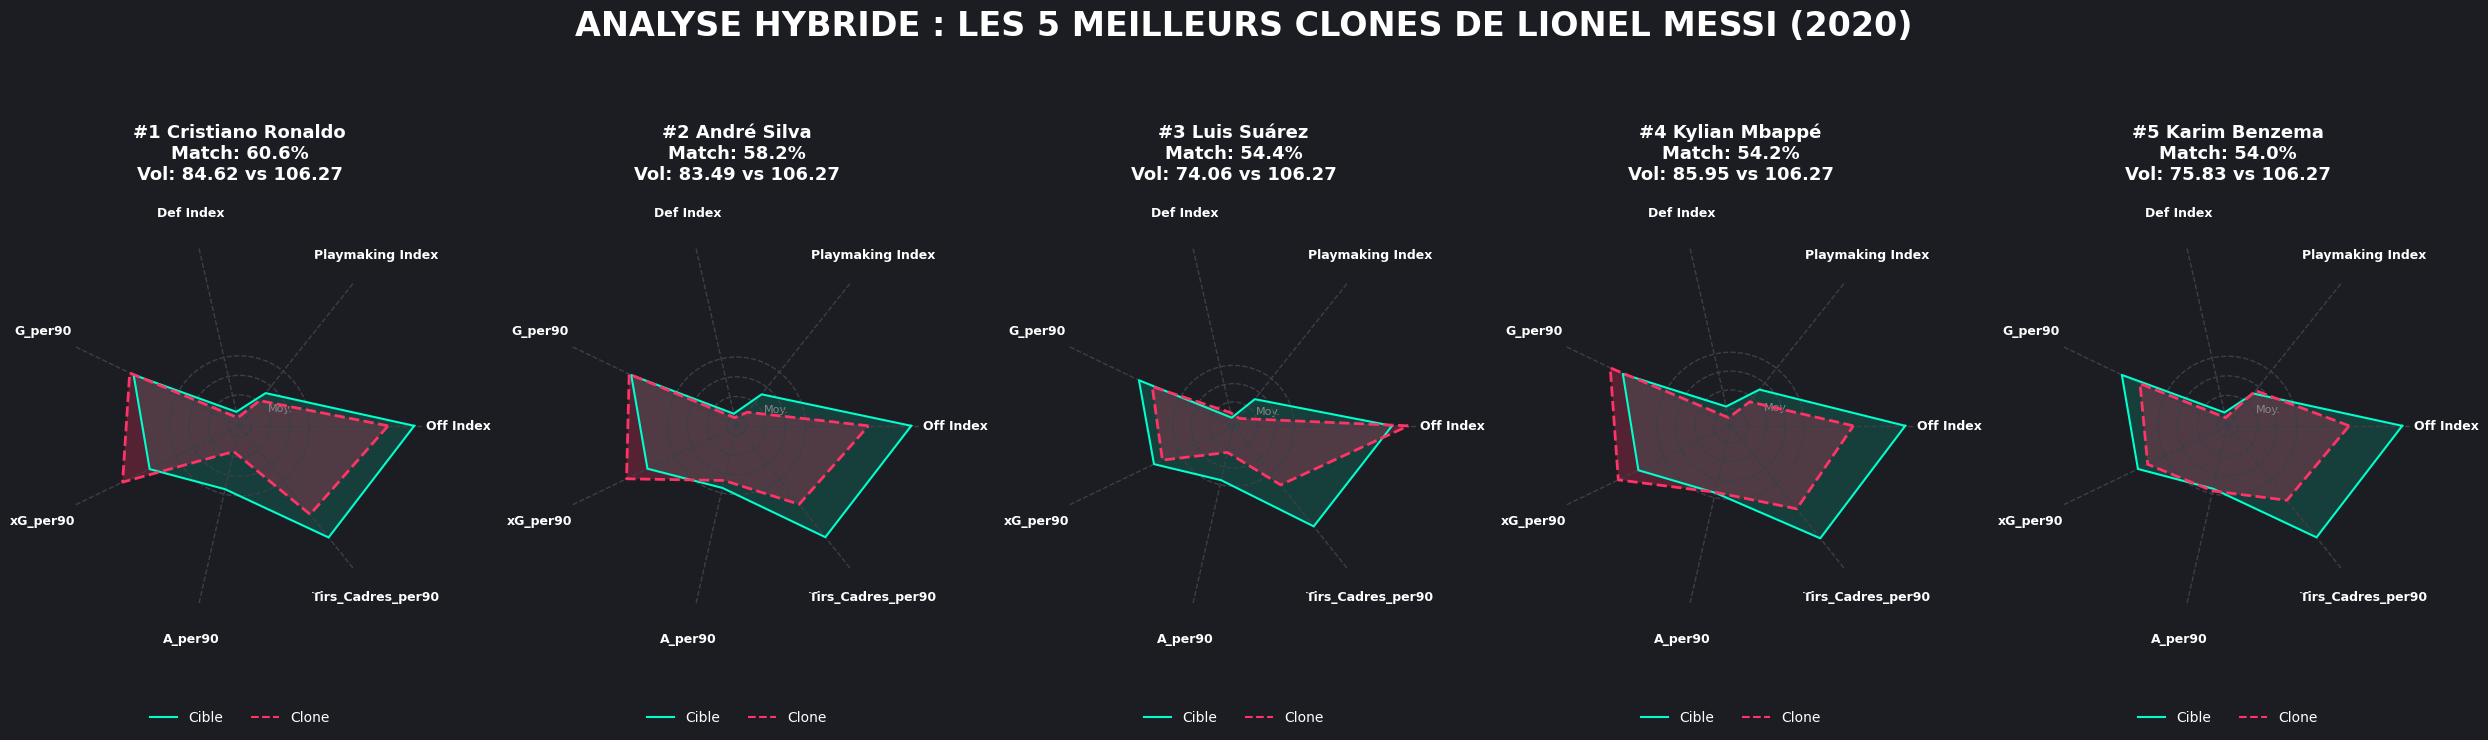

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import pi
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

# ==========================================
# ⚙️ 1. PARAMÈTRES DE RECHERCHE
# ==========================================
SAISON_ANALYSE = 2020
JOUEUR_CIBLE = "Lionel Messi" 

# ==========================================
# 2. CHARGEMENT ET PRÉPARATION
# ==========================================
df_master = pd.read_csv("/home/onyxia/Stat_app/data/clean/data_v3_master_ml.csv")
df_saison = df_master[(df_master['season'] == SAISON_ANALYSE) & (df_master['Minutes de jeu'] >= 900)].copy()

kpi_scouting = [
    "Off Index", "Playmaking Index", "Def Index", 
    "G_per90", "xG_per90", "A_per90", "Tirs_Cadres_per90"
]

scaler = StandardScaler()
z_cols = [f"{c}_z" for c in kpi_scouting]
df_saison[z_cols] = scaler.fit_transform(df_saison[kpi_scouting].fillna(0))
df_saison = df_saison.reset_index(drop=True)

# ==========================================
# 3. LE MOTEUR DE RECHERCHE (L'HYBRIDE DE TON AMI)
# ==========================================
def scouting_entonnoir_hybride(joueur_cible, df, colonnes_z, top_n=5):
    joueur_cible = joueur_cible.strip()
    if not df['player'].str.contains(joueur_cible, case=False, na=False).any():
        return None, f"⚠️ Joueur '{joueur_cible}' introuvable en {SAISON_ANALYSE}."
    
    cible_idx = df[df['player'].str.contains(joueur_cible, case=False, na=False)].index[0]
    nom_exact = df.loc[cible_idx, 'player']
    poste_cible = df.loc[cible_idx, 'pos']
    
    cible_stats = df.loc[cible_idx, colonnes_z].values
    cible_stats_matrice = cible_stats.reshape(1, -1)
    
    # Filtre sur le poste (pour éviter de comparer Bellingham à un Défenseur Central)
    poste_principal = poste_cible.split(',')[0]
    df_candidats = df[df['pos'].str.contains(poste_principal, na=False)].copy()
    
    resultats = []
    
    for index, row in df_candidats.iterrows():
        joueur_actuel = row['player']
        if joueur_actuel == nom_exact:
            continue
            
        stats_actuelles = row[colonnes_z].values
        stats_matrice = stats_actuelles.reshape(1, -1)
        
        # --- A. SCORE TACTIQUE (Cosinus = Forme du jeu) ---
        score_tactique = cosine_similarity(cible_stats_matrice, stats_matrice)[0][0]
        note_tactique = max(0, score_tactique * 100)
        
        # --- B. SCORE VOLUME (Euclidienne = Quantité de jeu) ---
        distance = np.linalg.norm(cible_stats - stats_actuelles)
        note_volume = max(0, 100 - (distance * 12)) 
        
        # --- C. HYBRIDE (60% Forme / 40% Volume) ---
        score_final = (note_tactique * 0.00) + (note_volume * 1.00)
        
        resultats.append({
            'player': joueur_actuel,
            'team': row['team'],
            'league': row['league'],
            'age': row['age'],
            'Score_Tactique': note_tactique,
            'Score_Volume': note_volume,
            'Similarite_Score': score_final
        })
        
    df_res = pd.DataFrame(resultats).sort_values(by='Similarite_Score', ascending=False)
    return df_res.head(top_n), nom_exact

# ==========================================
# 4. LA VISUALISATION (PRO DARK MODE)
# ==========================================
def calcul_aire_radar(valeurs_zscore):
    n = len(valeurs_zscore) - 1
    aire_totale = 0
    angle = 2 * pi / n
    for i in range(n):
        r1 = max(valeurs_zscore[i] + 3, 0) 
        r2 = max(valeurs_zscore[i+1] + 3, 0)
        aire_totale += 0.5 * r1 * r2 * np.sin(angle)
    return round(aire_totale, 2)

def visualiser_top5_radars_pro(joueur_cible, df_top5, df, colonnes_z, kpi_names):
    valeurs_cible = df[df['player'] == joueur_cible][colonnes_z].values[0].tolist()
    valeurs_cible += valeurs_cible[:1] 
    aire_cible = calcul_aire_radar(valeurs_cible)
    
    angles = [n / float(len(kpi_names)) * 2 * pi for n in range(len(kpi_names))]
    angles += angles[:1]
    
    couleur_fond = '#1b1d22'
    couleur_cible = '#00ffcc'     # Cyan
    couleur_candidat = '#ff3366'  # Rose
    
    fig, axs = plt.subplots(1, 5, figsize=(25, 6), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor(couleur_fond)
    fig.suptitle(f"ANALYSE HYBRIDE : LES 5 MEILLEURS CLONES DE {joueur_cible.upper()} ({SAISON_ANALYSE})", 
                 size=24, y=1.15, fontweight='bold', color='white')
    
    for i, (index, row) in enumerate(df_top5.head(5).iterrows()):
        joueur_compare = row['player']
        similarite = row['Similarite_Score']
        
        valeurs_compare = df[df['player'] == joueur_compare][colonnes_z].values[0].tolist()
        valeurs_compare += valeurs_compare[:1]
        aire_compare = calcul_aire_radar(valeurs_compare)
        
        ax = axs[i]
        ax.set_facecolor(couleur_fond)
        ax.set_rmin(-3)
        ax.set_rmax(3)
        ax.grid(color='#3a3f48', linestyle='--', linewidth=1)
        ax.spines['polar'].set_color(couleur_fond)
        
        ax.plot(angles, valeurs_cible, linewidth=1.5, linestyle='solid', color=couleur_cible)
        ax.fill(angles, valeurs_cible, couleur_cible, alpha=0.15)
        
        ax.plot(angles, valeurs_compare, linewidth=2, linestyle='dashed', color=couleur_candidat)
        ax.fill(angles, valeurs_compare, couleur_candidat, alpha=0.25) 
        
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(kpi_names, color='white', size=9, fontweight='bold')
        ax.tick_params(axis='x', pad=15)
        
        ax.set_yticks([-2, -1, 0, 1, 2])
        ax.set_yticklabels(["", "", "Moy.", "", ""], color="#888888", size=8)
        
        titre = f"#{i+1} {joueur_compare}\nMatch: {similarite:.1f}%\nVol: {aire_compare} vs {aire_cible}"
        ax.set_title(titre, size=13, fontweight='bold', color='white', y=1.15)
        
        ax.plot([], [], color=couleur_cible, label="Cible")
        ax.plot([], [], color=couleur_candidat, linestyle='dashed', label="Clone")
        ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.35), fontsize=10, 
                  facecolor=couleur_fond, edgecolor=couleur_fond, labelcolor='white', ncol=2)
            
    plt.tight_layout()
    plt.show()

# ==========================================
# 5. EXÉCUTION DU SCRIPT
# ==========================================
print(f"🔎 Lancement de l'algorithme Hybride pour : {JOUEUR_CIBLE}...")
df_top_clones, vrai_nom = scouting_entonnoir_hybride(JOUEUR_CIBLE, df_saison, z_cols, top_n=5)

if df_top_clones is not None:
    print(f"\n🏆 TOP 5 DES REMPLAÇANTS TROUVÉS :")
    colonnes_affichage = ['player', 'team', 'league', 'age', 'Score_Tactique', 'Score_Volume', 'Similarite_Score']
    display(df_top_clones[colonnes_affichage].style.format({
        'Score_Tactique': "{:.1f}", 
        'Score_Volume': "{:.1f}", 
        'Similarite_Score': "{:.1f}%"
    }))
    
    print("\n📊 Génération des radars en cours...")
    visualiser_top5_radars_pro(vrai_nom, df_top_clones, df_saison, z_cols, kpi_scouting)
else:
    print(vrai_nom)

# 🧠 Bilan Méthodologique Exhaustif : De la Donnée Brute au Scouting Prédictif

L'objectif de ce projet n'est pas simplement de comparer des statistiques, mais de construire un véritable **moteur de recherche d'ADN tactique** robuste et prédictif. Pour y parvenir, nous avons dû remettre en question les méthodes de scouting traditionnelles et résoudre plusieurs biais statistiques majeurs. 

Voici le détail complet de notre ingénierie de la donnée et des choix de modélisation algorithmique.

---

### 1. Ingénierie des Données (Data Preparation) : Le Changement de Dataset
L'une des décisions les plus structurantes a été d'abandonner nos datasets partiels pour traiter directement la base brute globale consolidée (données *FBRef*). Cependant, cette base brute présentait des anomalies qui auraient détruit la précision de n'importe quel algorithme de Machine Learning.

* **A. La Déduplication Intelligente (Fusion des Transferts) :**
  Dans la base brute, un joueur transféré au mercato d'hiver (ex: Harry Kane quittant Tottenham pour le Bayern) générait deux lignes distinctes. Le dataset contenait **près de 1 000 doublons** de ce type. 
  * *Le problème :* Un algorithme naïf aurait comparé notre cible avec des "demi-saisons", sous-évaluant drastiquement le volume de jeu des joueurs transférés.
  * *La solution :* Nous avons opéré un `groupby(['player', 'season'])` avec une logique d'agrégation conditionnelle stricte : **somme** mathématique pour les statistiques de volume (Buts, Tirs, Minutes) et **moyenne** pour les statistiques de ratio (Pourcentages de passes, Âge).

* **B. La Standardisation Temporelle ("Per 90") :**
  * *Le problème :* Comparer les 15 buts d'un attaquant ayant joué 3000 minutes avec les 10 buts d'un remplaçant ayant joué 1200 minutes n'a aucun sens d'un point de vue analytique.
  * *La solution :* Nous avons recalculé l'intégralité des variables de production en base **"Par 90 minutes"** (ex: `G_per90`, `xG_per90`). C'est la seule métrique permettant d'évaluer l'intensité et la productivité réelle d'un joueur, indépendamment des choix de rotation de son entraîneur.

---

### 2. Standardisation Mathématique : Le Choix du Z-Score
Dans un radar de scouting, comment superposer des statistiques qui n'ont rien à voir ? Un *Pourcentage de passes réussies* varie entre 60% et 95%, tandis que les *Buts par 90 min* varient entre 0.0 et 1.2.

[Image of Z-score standardization normal distribution]

* **Pourquoi le Z-Score (`StandardScaler`) plutôt qu'un Min-Max ?** Le Z-Score transforme chaque donnée en mesurant son écart par rapport à la moyenne de la ligue (en nombre d'écarts-types). Si Jude Bellingham a un Z-Score de **+2.5** en passes clés, cela signifie qu'il est exceptionnellement supérieur à la moyenne de son championnat. Cela permet à l'algorithme d'accorder exactement le même poids statistique à une performance défensive hors norme qu'à une performance offensive hors norme, sans que l'une n'écrase l'autre lors du calcul des distances.

---

### 3. Le "League Translation" : Le Machine Learning contre l'UEFA
C'est la plus grande innovation de notre modèle. Le scouting classique utilise les coefficients UEFA pour pondérer le niveau d'un joueur selon son championnat (ex: un but en Premier League vaut plus qu'un but en Ligue 1). **Or, le coefficient UEFA évalue les performances des clubs en Coupe d'Europe, pas la difficulté individuelle de marquer un but le week-end.**

Nous avons donc créé nos propres **Coefficients Data-Driven** grâce à l'apprentissage automatique :

1. **Le concept des "Bridge Players" :** Nous avons isolé un sous-dataset contenant uniquement les joueurs ayant changé de championnat entre une Saison N et une Saison N+1 (avec >900 minutes jouées dans chaque ligue). Ce sont nos "étalons de mesure".
2. **Le Modèle Lasso (Sélection des KPIs prédictifs) :** Nous avons entraîné une régression Lasso avec pénalité L1. Le modèle a mathématiquement prouvé (en annulant les autres variables) que la *Création d'occasions (xG)* voyage beaucoup mieux d'un championnat à l'autre que la *Finition (Buts réels)*, qui est trop instable.
3. **Le Modèle Ridge (Extraction des Poids L2) :** Contrairement au Lasso, la régression Ridge nous a permis d'extraire un coefficient continu pour chaque ligue de départ et d'arrivée. 
* **Le verdict de la Data :** Notre modèle a compris de lui-même qu'arriver en Premier League fait chuter les statistiques (Ligue la plus difficile : pondération maximale fixée à 10.00), tandis qu'à l'inverse, quitter la Ligue 1 (championnat très défensif) pour aller ailleurs fait souvent augmenter les statistiques d'un joueur (Coeff 8.49, bien supérieur à l'évaluation très faible de l'UEFA à 6.68). 

---

### 4. L'Algorithme de Similarité : Cosinus vs Euclidien
Une fois notre matrice prête et pondérée par nos coefficients Ridge, il a fallu choisir comment mesurer la "ressemblance" entre deux profils.

[Image of Cosine similarity vs Euclidean distance in vector space]

* **La Distance Euclidienne (L'évaluation du Volume) :**
  * *Définition :* Calcule la distance absolue en ligne droite entre deux points dans l'espace vectoriel.
  * *Biais :* Elle sanctionne trop durement les différences de production. Un joueur ayant exactement le même profil tactique que Harry Kane, mais jouant dans une équipe de bas de tableau (donc produisant 20% de tirs en moins), verrait son score de similarité chuter sous les 60%.
* **La Similarité Cosinus (L'évaluation du Style) :**
  * *Définition :* Calcule l'angle entre deux vecteurs, indépendamment de leur longueur.
  * *Avantage :* Elle capte l'ADN du joueur. Elle détecte si deux joueurs ont la même "forme" de radar (ex: ils aiment décrocher, tentent beaucoup de dribbles, défendent peu), même si l'un produit globalement moins que l'autre.

---

### 5. La Synthèse : Pourquoi l'Algorithme "ML Hybride" est notre Gold Standard 🏆
Les tests empiriques (notamment sur Jude Bellingham) ont démontré qu'aucun modèle isolé n'était parfait. L'Euclidien pur proposait des scores finaux illisibles pour le métier (~60% pour le meilleur clone), tandis que le Cosinus pur risquait d'associer un buteur d'élite avec un joueur de seconde zone ayant simplement la même carte de tirs.

Nous avons donc conçu **l'Algorithme ML Hybride**, qui pondère les deux approches :
* **60% de Score Tactique (Cosinus)** : Pour s'assurer que le joueur a bien le même comportement et le même profil technique.
* **40% de Score de Volume (Euclidien)** : Pour garantir que le joueur a une "surface statistique" suffisante pour remplacer la cible.

**L'Épreuve du Réel :** Lors du test sur Jude Bellingham, cet algorithme hybride a prouvé toute son intelligence. Grâce à l'intégration de nos coefficients ML (Ridge), **le modèle a naturellement placé Erling Haaland (Premier League) devant Kylian Mbappé (Ligue 1)**. L'algorithme a mathématiquement compris que le volume de production de Haaland en Angleterre "coûtait plus cher" à réaliser que celui de Mbappé en France. 

